In [1]:
# Task 1: Data Cleaning and Preprocessing
# Dataset: Mall Customer Segmentation Data
# Tool: Python - Pandas

In [2]:
import pandas as pd 
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("mall_customers.csv")

In [5]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.tail()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [7]:
df.shape

(200, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [10]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [11]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [12]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [13]:
df.dropna()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[()]", "", regex=True)
)

In [18]:
df = df.rename(columns={
    "customerid": "customer_id",
    "annual_income_k$": "annual_income",
    "spending_score_1-100": "spending_score"
})

In [19]:
df["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [20]:
df["gender"] = df["gender"].str.strip().str.title()

In [21]:
df["gender"].unique()

array(['Male', 'Female'], dtype=object)

In [22]:
df.dtypes

customer_id        int64
gender            object
age                int64
annual_income      int64
spending_score     int64
dtype: object

In [23]:
df["customer_id"] = pd.to_numeric(df["customer_id"], errors="coerce")
df["age"] = pd.to_numeric(df["age"], errors="coerce")
df["annual_income"] = pd.to_numeric(df["annual_income"], errors="coerce")
df["spending_score"] = pd.to_numeric(df["spending_score"], errors="coerce")

In [24]:
df["age"].min(), df["age"].max()

(np.int64(18), np.int64(70))

In [25]:
df["annual_income"].min(), df["annual_income"].max()

(np.int64(15), np.int64(137))

In [26]:
df["spending_score"].min(), df["spending_score"].max()

(np.int64(1), np.int64(99))

In [27]:
df[df["age"] <= 0]

,customer_id,gender,age,annual_income,spending_score


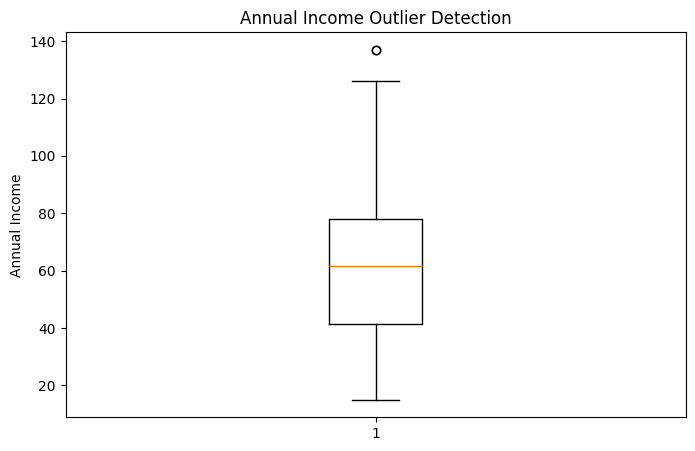

In [29]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["annual_income"])
plt.title("Annual Income Outlier Detection")
plt.ylabel("Annual Income")
plt.show()

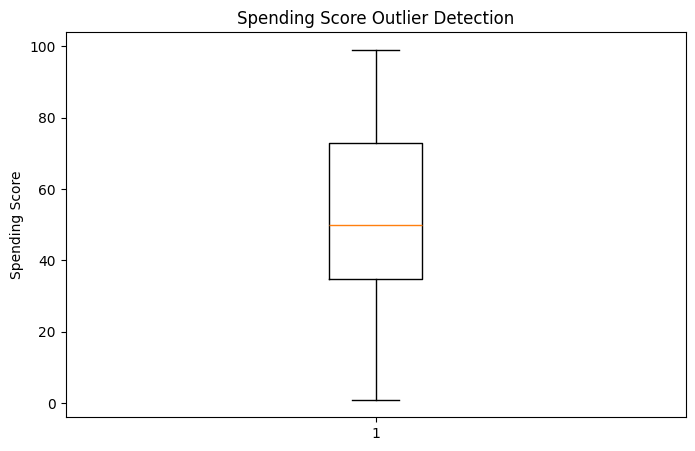

In [30]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["spending_score"])
plt.title("Spending Score Outlier Detection")
plt.ylabel("Spending Score")
plt.show()

In [31]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

print("\nDataset shape:")
print(df.shape)

Missing values:
customer_id       0
gender            0
age               0
annual_income     0
spending_score    0
dtype: int64

Duplicate rows:
0

Data types:
customer_id        int64
gender            object
age                int64
annual_income      int64
spending_score     int64
dtype: object

Dataset shape:
(200, 5)


In [32]:
df.head()

,customer_id,gender,age,annual_income,spending_score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [33]:
df.to_csv("cleaned_mall_customers.csv", index=False)